In [1]:
import os
import scanpy as sc
import anndata as ad
import tarfile
import re
import shutil

import anndata as ad

In [ ]:
# Define the sample list based on your .tar.gz file names
samples = [
    "GSM5957560_Total_T0",
    "GSM5957561_CD34_T0",
    "GSM5957562_Total_T4",
    "GSM5957563_CD34_T4",
    "GSM5957564_Total_T12",
    "GSM5957565_CD34_T12",
    "GSM5957566_CD34_T4_BMT"
]

# Set paths relative to your notebook location (script/Data_Overview.ipynb)
data_dir = "../data/GSE198833_RAW"
adata_list = []

# Extract, parse metadata, and load each sample
for sample in samples:
    tar_filename = f"{sample}_filtered_feature_bc_matrix.tar.gz"
    tar_path = os.path.join(data_dir, tar_filename)
    
    # --- Parse Phenotype and Timeline Metadata ---
    # Matches patterns like GSMxxxxx_Phenotype_Timeline
    match = re.match(r"GSM\d+_(Total|CD34)_(T\d+(?:_BMT)?)", sample)
    if match:
        phenotype = match.group(1)  # Extracts 'Total' or 'CD34'
        timeline = match.group(2)   # Extracts 'T0', 'T4', 'T12', or 'T4_BMT'
    else:
        phenotype = "Unknown"
        timeline = "Unknown"

    # Step A: Automatically extract the .tar.gz archive
    if os.path.exists(tar_path):
        print(f"Extracting: {tar_filename}...")
        try:
            with tarfile.open(tar_path, "r:gz") as tar:
                tar.extractall(path=data_dir)
        except Exception as e:
            print(f"Extraction failed for {tar_filename}: {e}")
            continue
    else:
        print(f"Archive not found: {tar_path}. Checking if already extracted...")

    # Step B: Locate the internal 10x Genomics folder structure
    matrix_path = os.path.join(data_dir, "filtered_feature_bc_matrix/")
    
    # Step C: Read the data using Scanpy and append parsed metadata
    if os.path.exists(matrix_path):
        print(f"Loading data for {sample} | Phenotype: {phenotype} | Timeline: {timeline}")
        try:
            adata = sc.read_10x_mtx(matrix_path, var_names='gene_symbols', cache=False)
            
            # Add metadata columns to track cell characteristics
            adata.obs['sample'] = sample
            adata.obs['phenotype'] = phenotype
            adata.obs['timeline'] = timeline
            
            # Prevent duplicate barcode conflicts across samples
            adata.obs_names = [f"{barcode}-{sample}" for barcode in adata.obs_names]
            
            adata_list.append(adata)
            
            # Rename the folder to avoid mix-ups in the next loop execution
            extracted_rename_path = os.path.join(data_dir, f"{sample}_extracted_matrix")
            if os.path.exists(extracted_rename_path):
                shutil.rmtree(extracted_rename_path)
            os.rename(matrix_path, extracted_rename_path)
            
        except Exception as e:
            print(f"Error processing AnnData for {sample}: {e}")
    else:
        print(f"Expected folder structure not found for {sample}")

# Merge (concatenate) all single-cell samples
if adata_list:
    print("\nMerging all samples...")
    # 'inner' join keeps only the overlapping features across all datasets
    combined_adata = ad.concat(adata_list, join='inner')
    
    # Enforce unique gene identifiers
    combined_adata.var_names_make_unique()
    
    print("\n--- Pipeline Completed Successfully! ---")
    print(combined_adata)
else:
    print("\n[Error] No data was loaded. Please verify your file paths.")


Extracting: GSM5957560_Total_T0_filtered_feature_bc_matrix.tar.gz...
Loading data for GSM5957560_Total_T0 | Phenotype: Total | Timeline: T0
Extracting: GSM5957561_CD34_T0_filtered_feature_bc_matrix.tar.gz...
Loading data for GSM5957561_CD34_T0 | Phenotype: CD34 | Timeline: T0
Extracting: GSM5957562_Total_T4_filtered_feature_bc_matrix.tar.gz...
Loading data for GSM5957562_Total_T4 | Phenotype: Total | Timeline: T4
Extracting: GSM5957563_CD34_T4_filtered_feature_bc_matrix.tar.gz...
Loading data for GSM5957563_CD34_T4 | Phenotype: CD34 | Timeline: T4
Extracting: GSM5957564_Total_T12_filtered_feature_bc_matrix.tar.gz...
Loading data for GSM5957564_Total_T12 | Phenotype: Total | Timeline: T12
Extracting: GSM5957565_CD34_T12_filtered_feature_bc_matrix.tar.gz...
Loading data for GSM5957565_CD34_T12 | Phenotype: CD34 | Timeline: T12
Extracting: GSM5957566_CD34_T4_BMT_filtered_feature_bc_matrix.tar.gz...
Loading data for GSM5957566_CD34_T4_BMT | Phenotype: CD34 | Timeline: T4_BMT

Merging all s

In [3]:
import os

# Define the file path within your data directory
save_path = os.path.join("../data/", "combined_heart_failure_adata.h5ad")

print(f"Saving combined AnnData object to: {save_path}...")

# Write the object to disk (compression='gzip' saves disk space in Colab)
combined_adata.write(save_path)

print("--- File Saved Successfully! ---")

Saving combined AnnData object to: ../data/combined_heart_failure_adata.h5ad...
--- File Saved Successfully! ---


Standardizing and preprocessing data...


/home/vasileioubill95/miniconda3/envs/maria/lib/python3.14/functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Computing PCA and UMAP...


/home/vasileioubill95/miniconda3/envs/maria/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating visualization plots...


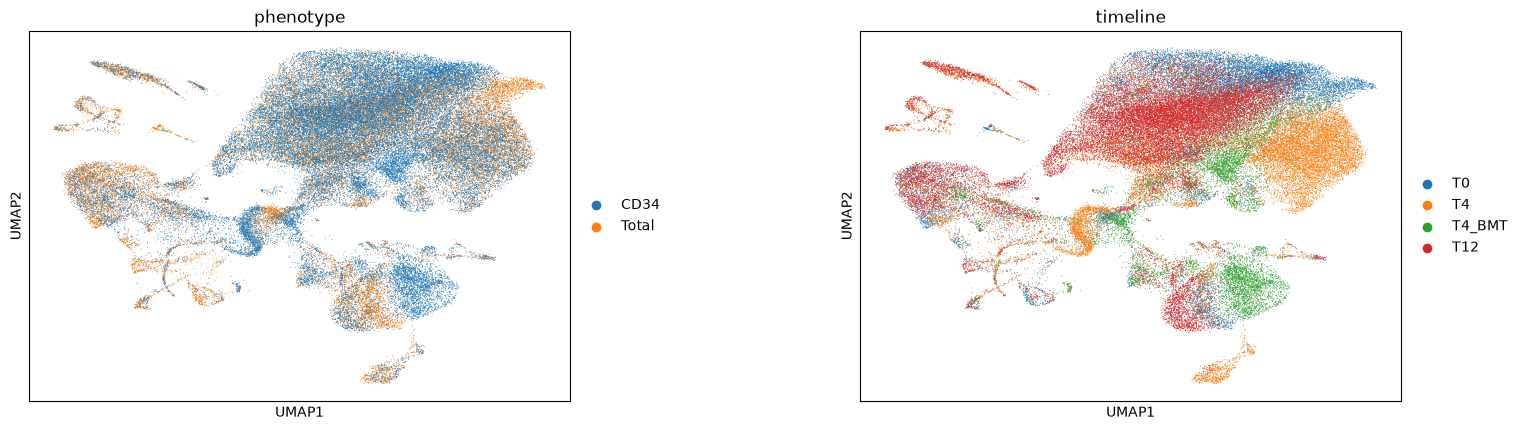

In [4]:
import scanpy as sc
import matplotlib.pyplot as plt

# Preprocessing (Required prior to PCA/UMAP)
print("Standardizing and preprocessing data...")

# Save raw counts matrix in .raw before filtering/normalization
combined_adata.raw = combined_adata

# Normalize total counts per cell to 10,000
sc.pp.normalize_total(combined_adata, target_sum=1e4)

# Logarithmize the data
sc.pp.log1p(combined_adata)

# Identify highly variable genes across cells
sc.pp.highly_variable_genes(combined_adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

# Keep a subset of only highly variable genes for dimensionality reduction
adata_hvg = combined_adata[:, combined_adata.var.highly_variable].copy()

# Scale data to unit variance and zero mean
sc.pp.scale(adata_hvg, max_value=10)


# Dimensionality Reduction (PCA & Neighborhood Graph)
print("Computing PCA and UMAP...")

# Run Principal Component Analysis
sc.tl.pca(adata_hvg, svd_solver='arpack')

# Compute neighborhood graph using the top PCA components
sc.pp.neighbors(adata_hvg, n_neighbors=10, n_pcs=40)

# Compute UMAP embedding coordinates
sc.tl.umap(adata_hvg)


# Visualization
print("Generating visualization plots...")

# Plot UMAP colored by Phenotype and Timeline side by side
sc.pl.umap(
    adata_hvg, 
    color=['phenotype', 'timeline'], 
    wspace=0.4, 
    show=False
)

# Render the plots inside Colab
plt.show()
